## Contents

1. Objective
2. Dataset Overview
3. Feature Engineering Roadmap
4. Feature 1: Average Monthly Spend
5. Feature 2: Total Services Used
6. Feature 3: HasFamily
7. Feature 4: TenureGroup
8. Feature 5: SpendingGroup
9. Feature Evaluation
10. Correlation Analysis
11. Save Dataset
12. Summary

# Feature Engineering

## Customer Churn Prediction Platform

### Objective

The purpose of this notebook is to create meaningful features from the cleaned customer churn dataset.

Feature engineering transforms existing variables into more informative features that better capture customer behaviour and improve machine learning performance.

Unlike data cleaning, feature engineering focuses on creating new predictive information rather than correcting data quality issues.

### Goals

- Create business-driven features
- Validate each engineered feature
- Document the motivation behind every feature
- Save the engineered dataset for model training

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/telco_cleaned.csv")

In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.info()

Rows : 7032
Columns : 22
<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-n

## Dataset Overview

The cleaned dataset from the previous notebook is loaded.

This dataset will serve as the foundation for creating new business-oriented features before model training.

In [4]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'Churn_Binary']

In [3]:
if "customerID" in df.columns:
    df.drop(columns=["customerID"], inplace=True)

# Feature Engineering Roadmap

The following business-driven features will be created:

1. Average Monthly Spend
2. Total Services Used
3. Family Customer Indicator
4. Customer Tenure Group
5. Monthly Spending Group
6. Internet User Category

Each feature will include:

- Business Motivation
- Technical Implementation
- Validation
- Business Insight

# Feature 1: Average Monthly Spend

## Business Motivation

The `TotalCharges` feature represents the total amount a customer has paid since joining the company.

However, customers with the same TotalCharges may have very different spending patterns because they have different tenures.

For example:

| Customer | Tenure | TotalCharges |
|----------|--------|--------------|
| A | 2 months | ₹200 |
| B | 20 months | ₹200 |

Although both customers have paid ₹200 in total, Customer A spends ₹100 per month while Customer B spends only ₹10 per month.

To better capture customer spending behaviour, we create a new feature called **Average Monthly Spend**.

This feature may provide stronger predictive information than TotalCharges alone.

In [6]:
df["AvgMonthlySpend"] = np.where(
    df["tenure"] == 0,
    0,
    df["TotalCharges"] / df["tenure"]
)

In [8]:
df["AvgMonthlySpend"].describe()

count    7032.000000
mean       64.799424
std        30.185891
min        13.775000
25%        36.179891
50%        70.373239
75%        90.179560
max       121.400000
Name: AvgMonthlySpend, dtype: float64

In [12]:
df.groupby("Churn")["AvgMonthlySpend"].mean()

Churn
No     61.312024
Yes    74.433154
Name: AvgMonthlySpend, dtype: float64

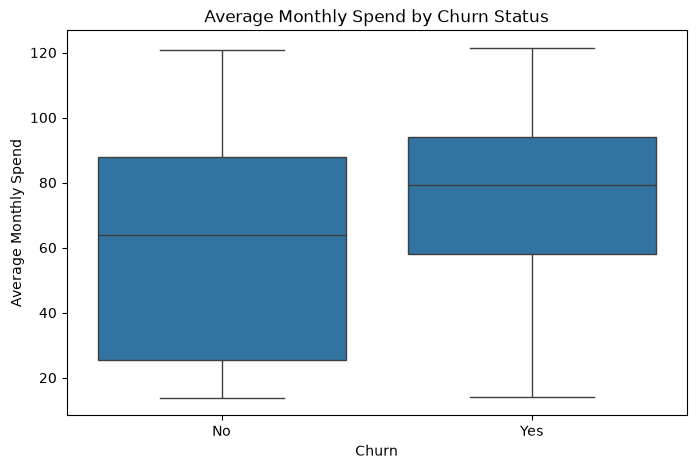

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="AvgMonthlySpend"
)

plt.title("Average Monthly Spend by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Spend")

plt.show()


## Business Insight

The engineered feature **Average Monthly Spend** captures customer spending intensity rather than cumulative spending.

Exploratory analysis shows that customers who churn have a higher average monthly spend (₹74.43) compared to customers who remain with the company (₹61.31).

This suggests that customers paying higher monthly amounts may have greater expectations regarding service quality and value. If these expectations are not met, they may be more likely to leave.

Based on this observation, **Average Monthly Spend** will be retained as a predictive feature for model training.

# Feature 2: Total Services Used

## Business Motivation

Customers often subscribe to multiple telecom services beyond their primary internet or phone connection.

A customer using many services is generally more integrated into the company's ecosystem and may exhibit different churn behaviour than a customer using only one or two services.

To capture overall service adoption, a new feature called **Total Services Used** will be created by counting the number of subscribed services.

In [13]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["TotalServices"] = (
    df[service_columns]
    .isin(["Yes"])
    .sum(axis=1)
)

In [15]:
df["TotalServices"].describe()

count    7032.000000
mean        3.363339
std         2.062067
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max         8.000000
Name: TotalServices, dtype: float64

In [16]:
df.groupby("Churn")["TotalServices"].mean()

Churn
No     3.447027
Yes    3.132156
Name: TotalServices, dtype: float64

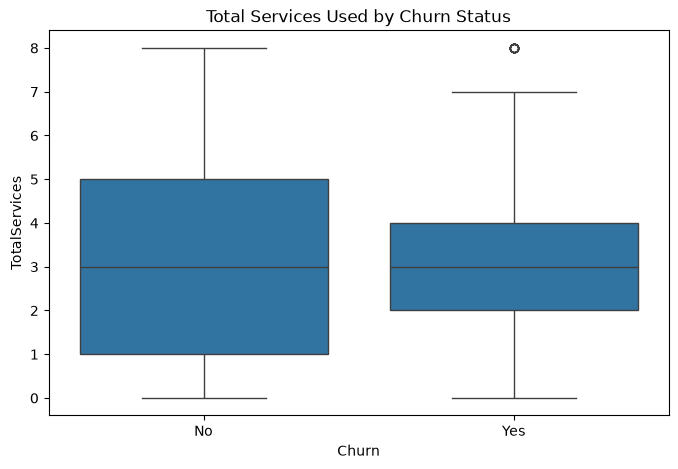

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalServices"
)

plt.title("Total Services Used by Churn Status")

plt.show()

## Business Insight

The engineered feature **Total Services Used** measures customer engagement by counting the number of telecom services subscribed to.

Exploratory analysis indicates that customers who remain with the company use slightly more services on average (3.45) than customers who churn (3.13).

Although the separation between the two groups is moderate, this feature captures customer engagement and service adoption, making it a meaningful predictor for machine learning models.

The feature will be retained for model training.

# Feature 3: Family Customer Indicator

## Business Motivation

Customers with family responsibilities may exhibit different churn behaviour compared to individual customers.

Instead of considering the `Partner` and `Dependents` columns independently, these two attributes are combined into a single feature called **HasFamily**.

This feature represents whether a customer has both a partner and dependents, potentially indicating stronger household commitment and long-term service usage.

In [18]:
df["HasFamily"] = (
    (df["Partner"] == "Yes") &
    (df["Dependents"] == "Yes")
).astype(int)

In [19]:
df["HasFamily"].value_counts()

HasFamily
0    5292
1    1740
Name: count, dtype: int64

In [20]:
df.groupby("Churn")["HasFamily"].mean()

Churn
No     0.288786
Yes    0.133226
Name: HasFamily, dtype: float64

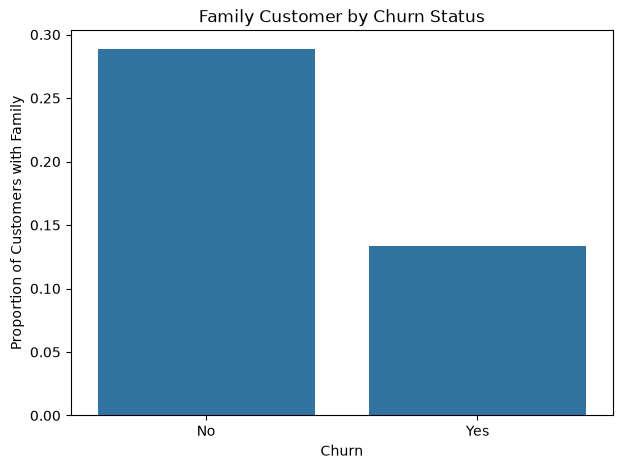

In [21]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Churn",
    y="HasFamily",
    estimator="mean",
    errorbar=None
)

plt.title("Family Customer by Churn Status")
plt.ylabel("Proportion of Customers with Family")

plt.show()

## Business Insight

The engineered feature **HasFamily** combines partner and dependent information into a single indicator of household stability.

Analysis shows that approximately **28.9%** of customers who remained with the company have both a partner and dependents, compared to only **13.3%** of customers who churned.

This suggests that customers with stronger family commitments are considerably less likely to leave the service provider.

The feature demonstrates clear separation between churned and non-churned customers and will be retained for model training.

# Feature 4: Customer Tenure Group

## Business Motivation

The numerical tenure variable indicates the number of months a customer has remained with the company.

From a business perspective, customers are often segmented into lifecycle stages rather than treated as exact numerical values.

To better represent customer maturity, tenure is grouped into meaningful categories:

- New Customer
- Growing Customer
- Established Customer
- Loyal Customer

This feature may help the model identify differences in churn behaviour across different stages of the customer lifecycle.

In [22]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "New",
        "Growing",
        "Established",
        "Loyal"
    ],
    include_lowest=True
)

In [25]:
(
    pd.crosstab(
        df["TenureGroup"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

Churn,No,Yes
TenureGroup,,
New,52.32,47.68
Growing,71.29,28.71
Established,79.61,20.39
Loyal,90.49,9.51


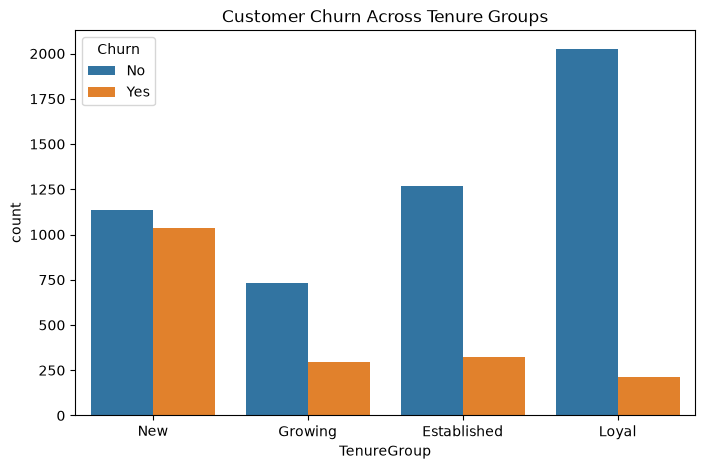

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="TenureGroup",
    hue="Churn"
)

plt.title("Customer Churn Across Tenure Groups")

plt.show()

## Business Insight

The engineered feature **TenureGroup** segments customers into different stages of their lifecycle.

Analysis reveals a strong inverse relationship between customer tenure and churn.

- Nearly **48%** of new customers churn.
- Churn decreases steadily as tenure increases.
- Only **9.5%** of loyal customers churn.

This indicates that customer retention improves significantly as relationships with the company mature.

The feature provides strong business interpretability and will be retained for model training.

# Feature 5: Spending Category

## Business Motivation

MonthlyCharges is a continuous numerical feature.

From a business perspective, customers are often grouped into spending segments instead of using exact billing values.

Segmenting customers into **Low**, **Medium**, and **High** spending groups makes the data easier to interpret and allows the business to identify which spending segment is most likely to churn.

This feature can also support targeted retention campaigns for different customer segments.

In [27]:
df["SpendingGroup"] = pd.qcut(
    df["MonthlyCharges"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [28]:
(
    pd.crosstab(
        df["SpendingGroup"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

Churn,No,Yes
SpendingGroup,,
Low,84.09,15.91
Medium,70.23,29.77
High,65.93,34.07


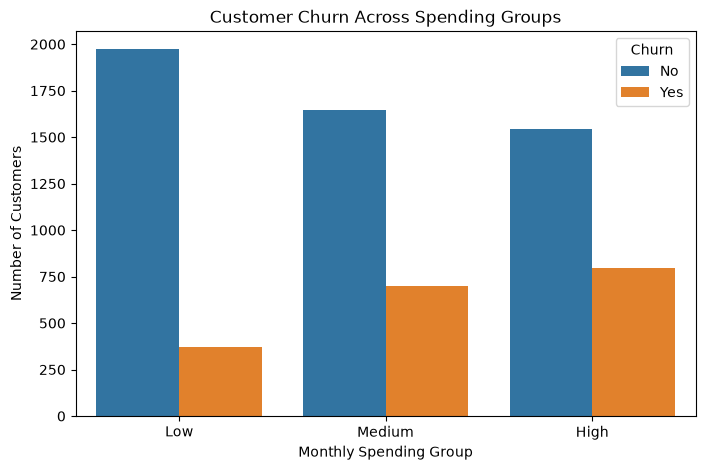

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="SpendingGroup",
    hue="Churn"
)

plt.title("Customer Churn Across Spending Groups")

plt.xlabel("Monthly Spending Group")
plt.ylabel("Number of Customers")

plt.show()

## Business Insight

The engineered feature **SpendingGroup** segments customers into low, medium, and high monthly spending categories.

Analysis reveals a clear relationship between spending level and churn.

- Low spending customers have a churn rate of **15.91%**.
- Medium spending customers have a churn rate of **29.77%**.
- High spending customers have the highest churn rate at **34.07%**.

This suggests that customers paying higher monthly charges may have higher expectations regarding service quality and value. If these expectations are not met, they are more likely to leave.

The feature provides strong business interpretability and will be retained for model training.

# Feature Redundancy Analysis

## Objective

Several engineered features were created from existing variables.

Before using them for model training, it is important to understand whether these new features provide additional information or simply duplicate existing features.

The final decision regarding feature selection will be based on both business understanding and model performance.

In [30]:
engineered_numeric = [
    "AvgMonthlySpend",
    "TotalServices",
    "HasFamily",
    "Churn_Binary"
]

corr = df[engineered_numeric].corr()

corr

,AvgMonthlySpend,TotalServices,HasFamily,Churn_Binary
AvgMonthlySpend,1.000000,0.800408,-0.071419,0.192033
TotalServices,0.800408,1.000000,0.061659,-0.067459
HasFamily,-0.071419,0.061659,1.000000,-0.159245
Churn_Binary,0.192033,-0.067459,-0.159245,1.000000


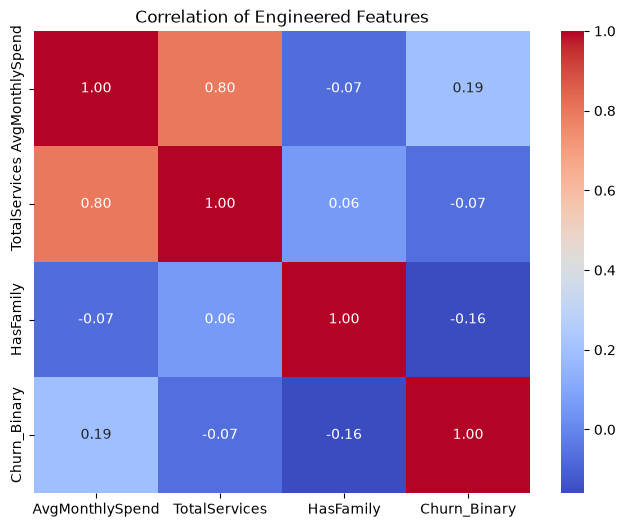

In [31]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation of Engineered Features")

plt.show()

## Business Insight

The correlation matrix provides a quantitative view of how the engineered numerical features relate to customer churn.

Although correlation alone does not determine predictive importance, it helps identify useful relationships and potential redundancy among engineered variables.

In [33]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary,AvgMonthlySpend,TotalServices,HasFamily,TenureGroup,SpendingGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Electronic check,29.85,29.85,No,0,29.850000,1,0,New,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Mailed check,56.95,1889.50,No,0,55.573529,3,0,Established,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Mailed check,53.85,108.15,Yes,1,54.075000,3,0,New,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Bank transfer (automatic),42.30,1840.75,No,0,40.905556,3,0,Established,Low
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Electronic check,70.70,151.65,Yes,1,75.825000,1,0,New,Medium


In [34]:
df.to_csv(
    "../data/processed/telco_feature_engineered.csv",
    index=False
)

print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.


# Notebook Summary

## Features Created

- Average Monthly Spend
- Total Services Used
- Family Customer Indicator
- Customer Tenure Group
- Spending Group

## Key Findings

- Customers with higher monthly spending tend to churn more frequently.
- Family customers demonstrate stronger retention.
- Long-tenure customers have significantly lower churn rates.
- Customers using more services show slightly better retention.
- Engineered features improve business interpretability and may enhance predictive performance.

## Output

The feature-engineered dataset has been saved and is ready for model training.

## Conclusion

Five business-driven features were engineered and validated using exploratory analysis.

These features capture:

- Customer spending behaviour
- Customer engagement
- Household stability
- Customer lifecycle
- Spending segmentation

The resulting dataset will be used to train and compare multiple machine learning models in the next notebook.